### Import Necessary Libraries

In [1]:
# Import necessary packages
import warnings
import pandas as pd
import numpy as np
import string
import re
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP-related imports
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Scikit-learn imports for model evaluation and preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, roc_curve, auc, confusion_matrix)

# PyTorch imports for building and training neural networks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Data processing imports from torchtext (if needed)
from transformers import AutoTokenizer # For loading a pre-trained tokenizer

# Suppress specific warnings
warnings.filterwarnings("ignore", message=r".*datetime\.datetime\.utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

### Data preprocessing

##### Load Data

In [2]:
raw_data = pd.read_csv('/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv',encoding='ISO-8859-1', header=None).sample(n=100000)

In [3]:
raw_data = raw_data.reset_index(drop=True)

In [4]:
raw_data.head()

,0,1,2,3,4,5
0,0,1677939037,Sat May 02 04:46:18 PDT 2009,NO_QUERY,ginader,@mikewest very jealous! I totally love white a...
1,0,2260393581,Sat Jun 20 19:08:42 PDT 2009,NO_QUERY,JezHengmeister,is stuck between a rock &amp; a hard place. Wh...
2,0,2197316619,Tue Jun 16 13:37:32 PDT 2009,NO_QUERY,DWsLala,@donniewahlberg that was nt a good memory for ...
3,0,1962653785,Fri May 29 11:24:04 PDT 2009,NO_QUERY,barbaraaragao,@tommcfly and you only respond to ddlovato th...
4,4,2002748479,Tue Jun 02 05:03:42 PDT 2009,NO_QUERY,Futuremusic_CEO,@QueenoftheBeats um is there a game or rain or...


In [5]:
train, test = train_test_split(
    raw_data,
    test_size=0.2,    # 20% of data for testing
    random_state=42,  # for reproducible splits
    shuffle=True      # ensures random distribution
)

In [6]:
train.head()

,0,1,2,3,4,5
75220,4,2069212794,Sun Jun 07 15:28:06 PDT 2009,NO_QUERY,JenaJohnson,@DerekJCormier I want to see that! I saw 'The ...
48955,4,2067740482,Sun Jun 07 12:52:38 PDT 2009,NO_QUERY,AWeth,I just got a shiny new bike! Sweet graduation ...
44966,0,2001209268,Tue Jun 02 00:09:57 PDT 2009,NO_QUERY,QuickBlondie,"Sick on the train, sick on the train, oh it su..."
13568,0,1991172985,Mon Jun 01 06:32:34 PDT 2009,NO_QUERY,MelissaHeckman,@MelissaHeckman Today would have been my grand...
92727,0,2260154957,Sat Jun 20 18:45:31 PDT 2009,NO_QUERY,LizzieluvsNiley,@WeAdoreNiley y isn't any1 at the concert post...


In [7]:
test.head()

,0,1,2,3,4,5
75721,4,2000618177,Mon Jun 01 22:31:57 PDT 2009,NO_QUERY,Fecruz,"I'm sleepy, I go to bed! GoodKnight friends!! ..."
80184,4,2188094531,Mon Jun 15 21:17:32 PDT 2009,NO_QUERY,amberdanae,Fun night time for bed!
19864,0,1881888550,Fri May 22 05:47:19 PDT 2009,NO_QUERY,googing,I'm still stuck in this crappy hospital bed! O...
76699,4,1795754564,Thu May 14 08:18:50 PDT 2009,NO_QUERY,theoae,Find our brand new podcast@http://feeds2.feedb...
92991,0,1989308497,Mon Jun 01 01:04:13 PDT 2009,NO_QUERY,trina_na_na,@beatrizisabel I forgot what a b**** it is to ...


In [8]:
train.to_csv('train.csv',header = None,index=False)
test.to_csv('test.csv',header= None,index=False)

In [9]:
#read the training set and test set
train = pd.read_csv('train.csv',header=None)
test= pd.read_csv('test.csv',header=None)

In [10]:
train.head()

,0,1,2,3,4,5
0,4,2069212794,Sun Jun 07 15:28:06 PDT 2009,NO_QUERY,JenaJohnson,@DerekJCormier I want to see that! I saw 'The ...
1,4,2067740482,Sun Jun 07 12:52:38 PDT 2009,NO_QUERY,AWeth,I just got a shiny new bike! Sweet graduation ...
2,0,2001209268,Tue Jun 02 00:09:57 PDT 2009,NO_QUERY,QuickBlondie,"Sick on the train, sick on the train, oh it su..."
3,0,1991172985,Mon Jun 01 06:32:34 PDT 2009,NO_QUERY,MelissaHeckman,@MelissaHeckman Today would have been my grand...
4,0,2260154957,Sat Jun 20 18:45:31 PDT 2009,NO_QUERY,LizzieluvsNiley,@WeAdoreNiley y isn't any1 at the concert post...


In [11]:
test.head()

,0,1,2,3,4,5
0,4,2000618177,Mon Jun 01 22:31:57 PDT 2009,NO_QUERY,Fecruz,"I'm sleepy, I go to bed! GoodKnight friends!! ..."
1,4,2188094531,Mon Jun 15 21:17:32 PDT 2009,NO_QUERY,amberdanae,Fun night time for bed!
2,0,1881888550,Fri May 22 05:47:19 PDT 2009,NO_QUERY,googing,I'm still stuck in this crappy hospital bed! O...
3,4,1795754564,Thu May 14 08:18:50 PDT 2009,NO_QUERY,theoae,Find our brand new podcast@http://feeds2.feedb...
4,0,1989308497,Mon Jun 01 01:04:13 PDT 2009,NO_QUERY,trina_na_na,@beatrizisabel I forgot what a b**** it is to ...


In [12]:
#Set the column name
train.columns = ['target', 'ids', 'data', 'flag','user','text']
test.columns = ['target', 'ids', 'data', 'flag','user','text']

In [13]:
#training set have 1280023 row and 6 column.
train.shape

(80000, 6)

In [14]:
#test set have 319977 row and 6 column.
test.shape

(20000, 6)

##### Data Preprocessing Functions

In [15]:
#Here is some function for data preprocessing
#remove URLs,punctuations,numbers,nonsensical
#convert emoticons
#remove stop word,frequency word and rare word
#Use PorterStemmer() for Stemming
#Use WordNetLemmatizer() for lemmatizations
#If you don't want to waste the time to run the code, you can just simply read the train_clean.pkl and test_clean.pkl file.
#Read the converted training set and test set
#train_clean= pd.read_pickle('train_clean.pkl')
#test_clean= pd.read_pickle('test_clean.pkl')

def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

def remove_numbers(text):
    return re.sub(r'\d+', '', text) 

def remove_nonsensical(text):
    return text.replace('\n', ' ').replace('\r', ' ')

#Dictionary for converting emoticons
EMOTICONS = {
    r":‑\)": "Happy face or smiley",
    r":\)": "Happy face or smiley",
    r":-\]": "Happy face or smiley",
    r":\]": "Happy face or smiley",
    r":-3": "Happy face smiley",
    r":3": "Happy face smiley",
    r":->": "Happy face smiley",
    r":>": "Happy face smiley",
    r"8-\)": "Happy face smiley",
    r":o\)": "Happy face smiley",
    r":-\}": "Happy face smiley",
    r":\}": "Happy face smiley",
    r":-\)": "Happy face smiley",
    r":c\)": "Happy face smiley",
    r":\^\)": "Happy face smiley",
    r"=\]": "Happy face smiley",
    r"=\)": "Happy face smiley",
    r":‑D": "Laughing, big grin or laugh with glasses",
    r":D": "Laughing, big grin or laugh with glasses",
    r"8‑D": "Laughing, big grin or laugh with glasses",
    r"8D": "Laughing, big grin or laugh with glasses",
    r"X‑D": "Laughing, big grin or laugh with glasses",
    r"XD": "Laughing, big grin or laugh with glasses",
    r"=D": "Laughing, big grin or laugh with glasses",
    r"=3": "Laughing, big grin or laugh with glasses",
    r"B\^D": "Laughing, big grin or laugh with glasses",
    r":-\)\)": "Very happy",
    r":‑\(": "Frown, sad, andry or pouting",
    r":-\(": "Frown, sad, andry or pouting",
    r":\(": "Frown, sad, andry or pouting",
    r":‑c": "Frown, sad, andry or pouting",
    r":c": "Frown, sad, andry or pouting",
    r":‑<": "Frown, sad, andry or pouting",
    r":<": "Frown, sad, andry or pouting",
    r":‑\[": "Frown, sad, andry or pouting",
    r":\[": "Frown, sad, andry or pouting",
    r":-\|\|": "Frown, sad, andry or pouting",
    r">:\[": "Frown, sad, andry or pouting",
    r":\{": "Frown, sad, andry or pouting",
    r":@": "Frown, sad, andry or pouting",
    r">:\(": "Frown, sad, andry or pouting",
    r":'‑\(": "Crying",
    r":'\(": "Crying",
    r":'‑\)": "Tears of happiness",
    r":'\)": "Tears of happiness",
    r"D‑':": "Horror",
    r"D:<": "Disgust",
    r"D:": "Sadness",
    r"D8": "Great dismay",
    r"D;": "Great dismay",
    r"D=": "Great dismay",
    r"DX": "Great dismay",
    r":‑O": "Surprise",
    r":O": "Surprise",
    r":‑o": "Surprise",
    r":o": "Surprise",
    r":-0": "Shock",
    r"8‑0": "Yawn",
    r">:O": "Yawn",
    r":-\*": "Kiss",
    r":\*": "Kiss",
    r":X": "Kiss",
    r";‑\)": "Wink or smirk",
    r";\)": "Wink or smirk",
    r"\*-\)": "Wink or smirk",
    r"\*\)": "Wink or smirk",
    r";‑\]": "Wink or smirk",
    r";\]": "Wink or smirk",
    r";\^\)": "Wink or smirk",
    r":‑,": "Wink or smirk",
    r";D": "Wink or smirk",
    r":‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"X‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"XP": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"d:": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"=p": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r">:P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":-[.]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":S": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":‑\|": "Straight face",
    r":\|": "Straight face",
    r":$": "Embarrassed or blushing",
    r":‑x": "Sealed lips or wearing braces or tongue-tied",
    r":x": "Sealed lips or wearing braces or tongue-tied",
    r":‑#": "Sealed lips or wearing braces or tongue-tied",
    r":#": "Sealed lips or wearing braces or tongue-tied",
    r":‑&": "Sealed lips or wearing braces or tongue-tied",
    r":&": "Sealed lips or wearing braces or tongue-tied",
    r"O:‑\)": "Angel, saint or innocent",
    r"O:\)": "Angel, saint or innocent",
    r"0:‑3": "Angel, saint or innocent",
    r"0:3": "Angel, saint or innocent",
    r"0:‑\)": "Angel, saint or innocent",
    r"0:\)": "Angel, saint or innocent",
    r":‑b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"0;\^\)": "Angel, saint or innocent",
    r">:‑\)": "Evil or devilish",
    r">:\)": "Evil or devilish",
    r"\}:‑\)": "Evil or devilish",
    r"\}:\)": "Evil or devilish",
    r"3:‑\)": "Evil or devilish",
    r"3:\)": "Evil or devilish",
    r">;\)": "Evil or devilish",
    r"\|;‑\)": "Cool",
    r"\|‑O": "Bored",
    r":‑J": "Tongue-in-cheek",
    r"#‑\)": "Party all night",
    r"%‑\)": "Drunk or confused",
    r"%\)": "Drunk or confused",
    r":-###..": "Being sick",
    r":###..": "Being sick",
    r"<:‑\|": "Dump",
    r"\(>_<\)": "Troubled",
    r"\(>_<\)>": "Troubled",
    r"\(';'\)": "Baby",
    r"\(\^\^>``": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(\^_\^;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(~_~;\) \(・\.・;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-\)zzz": "Sleeping",
    r"\(\^_-\)": "Wink",
    r"\(\(\+_\+\)\)": "Confused",
    r"\(\+o\+\)": "Confused",
    r"\(o\|o\)": "Ultraman",
    r"\^_\^": "Joyful",
    r"\(\^_\^\)/": "Joyful",
    r"\(\^O\^\)／": "Joyful",
    r"\(\^o\^\)／": "Joyful",
    r"\(__\)": "Kowtow as a sign of respect, or dogeza for apology",
    r"_\(\._\.\)_": "Kowtow as a sign of respect, or dogeza for apology",
    r"<\(_ _\)>": "Kowtow as a sign of respect, or dogeza for apology",
    r"<m\(__\)m>": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(__\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(_ _\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"\('_'\)": "Sad or Crying",
    r"\(/_;\)": "Sad or Crying",
    r"\(T_T\) \(;_;\)": "Sad or Crying",
    r"\(;_;": "Sad of Crying",
    r"\(;_:\)": "Sad or Crying",
    r"\(;O;\)": "Sad or Crying",
    r"\(:_;\)": "Sad or Crying",
    r"\(ToT\)": "Sad or Crying",
    r";_;": "Sad or Crying",
    r";-;": "Sad or Crying",
    r";n;": "Sad or Crying",
    r";;": "Sad or Crying",
    r"Q\.Q": "Sad or Crying",
    r"T\.T": "Sad or Crying",
    r"QQ": "Sad or Crying",
    r"Q_Q": "Sad or Crying",
    r"\(-\.-\)": "Shame",
    r"\(-_-\)": "Shame",
    r"\(一一\)": "Shame",
    r"\(；一_一\)": "Shame",
    r"\(=_=\)": "Tired",
    r"\(=\^\·\^=\)": "cat",
    r"\(=\^\·\·\^=\)": "cat",
    r"=_\^=": "cat",
    r"\(\.\.\)": "Looking down",
    r"\(\._\.\)": "Looking down",
    r"\^m\^": "Giggling with hand covering mouth",
    r"\(\・\・?": "Confusion",
    r"\(?_?\)": "Confusion",
    r">\^_\^<": "Normal Laugh",
    r"<\^!\^>": "Normal Laugh",
    r"\^/\^": "Normal Laugh",
    r"\（\*\^_\^\*）": "Normal Laugh",
    r"\(\^<\^\) \(\^\.\^\)": "Normal Laugh",
    r"\(^\^\)": "Normal Laugh",
    r"\(\^\.\^\)": "Normal Laugh",
    r"\(\^_\^\.\)": "Normal Laugh",
    r"\(\^_\^\)": "Normal Laugh",
    r"\(\^\^\)": "Normal Laugh",
    r"\(\^J\^\)": "Normal Laugh",
    r"\(\*\^\.\^\*\)": "Normal Laugh",
    r"\(\^—\^\）": "Normal Laugh",
    r"\(#\^\.\^#\)": "Normal Laugh",
    r"\（\^—\^\）": "Waving",
    r"\(;_;\)/~~~": "Waving",
    r"\(\^\.\^\)/~~~": "Waving",
    r"\(-_-\)/~~~ \($\·\·\)/~~~": "Waving",
    r"\(T_T\)/~~~": "Waving",
    r"\(ToT\)/~~~": "Waving",
    r"\(\*\^0\^\*\)": "Excited",
    r"\(\*_\*\)": "Amazed",
    r"\(\*_\*;": "Amazed",
    r"\(\+_\+\) \(@_@\)": "Amazed",
    r"\(\*\^\^\)v": "Laughing,Cheerful",
    r"\(\^_\^\)v": "Laughing,Cheerful",
    r"\(\(d[-_-]b\)\)": "Headphones,Listening to music",
    r'\(-"-\)': "Worried",
    r"\(ーー;\)": "Worried",
    r"\(\^0_0\^\)": "Eyeglasses",
    r"\(\＾ｖ\＾\)": "Happy",
    r"\(\＾ｕ\＾\)": "Happy",
    r"\(\^\)o\(\^\)": "Happy",
    r"\(\^O\^\)": "Happy",
    r"\(\^o\^\)": "Happy",
    r"\)\^o\^\(": "Happy",
    r":O o_O": "Surprised",
    r"o_0": "Surprised",
    r"o\.O": "Surprised",
    r"\(o\.o\)": "Surprised",
    r"oO": "Surprised",
    r"\(\*￣m￣\)": "Dissatisfied",
    r"\(‘A`\)": "Snubbed or Deflated"}

In [16]:
def convert_emoticons(text):
    for emot in EMOTICONS:
        text = re.sub(u'('+emot+')', "_".join(EMOTICONS[emot].replace(",","").split()), text)
    return text

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

def remove_freqwords(text):
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

def remove_rarewords(text):
    return " ".join([word for word in str(text).split() if word not in RAREWORDS])


def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

##### Preprocess the Training and Test Sets

In [17]:
# Convert the traing set
train["text"] = train["text"].str.lower()
train["text"] = train["text"].apply(lambda text: remove_urls(text))
PUNCT_TO_REMOVE = string.punctuation
train["text"] = train["text"].apply(lambda text: remove_punctuation(text))
train["text"] = train["text"].apply(lambda text: remove_numbers(text))
train["text"] = train["text"].apply(lambda text: remove_nonsensical(text))
train["text"] = train["text"].apply(lambda text: convert_emoticons(text))
STOPWORDS = set(stopwords.words('english'))
train["text"] = train["text"].apply(lambda text: remove_stopwords(text))
cnt = Counter()
for text in train["text"].values:
    for word in text.split():
        cnt[word] += 1     
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
train["text"] = train["text"].apply(lambda text: remove_freqwords(text))
n_rare_words = 10
RAREWORDS = set([w for (w, wc) in cnt.most_common()[:-n_rare_words-1:-1]])
train["text"] = train["text"].apply(lambda text: remove_rarewords(text))
stemmer = PorterStemmer()
train["text"] = train["text"].apply(lambda text: stem_words(text))
lemmatizer = WordNetLemmatizer()
train["text"] = train["text"].apply(lambda text: lemmatize_words(text))
train.head()

,target,ids,data,flag,user,text
0,4,2069212794,Sun Jun 07 15:28:06 PDT 2009,NO_QUERY,JenaJohnson,derekjcormi want see saw hangov yesterday lufk...
1,4,2067740482,Sun Jun 07 12:52:38 PDT 2009,NO_QUERY,AWeth,got shini new bike sweet graduat present mi padr
2,0,2001209268,Tue Jun 02 00:09:57 PDT 2009,NO_QUERY,QuickBlondie,sick train sick train oh suck sick train
3,0,1991172985,Mon Jun 01 06:32:34 PDT 2009,NO_QUERY,MelissaHeckman,melissaheckman would grandpa rd birthday
4,0,2260154957,Sat Jun 20 18:45:31 PDT 2009,NO_QUERY,LizzieluvsNiley,weadoreniley isnt concert post bt


In [18]:
test.head()

,target,ids,data,flag,user,text
0,4,2000618177,Mon Jun 01 22:31:57 PDT 2009,NO_QUERY,Fecruz,"I'm sleepy, I go to bed! GoodKnight friends!! ..."
1,4,2188094531,Mon Jun 15 21:17:32 PDT 2009,NO_QUERY,amberdanae,Fun night time for bed!
2,0,1881888550,Fri May 22 05:47:19 PDT 2009,NO_QUERY,googing,I'm still stuck in this crappy hospital bed! O...
3,4,1795754564,Thu May 14 08:18:50 PDT 2009,NO_QUERY,theoae,Find our brand new podcast@http://feeds2.feedb...
4,0,1989308497,Mon Jun 01 01:04:13 PDT 2009,NO_QUERY,trina_na_na,@beatrizisabel I forgot what a b**** it is to ...


In [19]:
#save the converted training set
train_clean = train.copy()
train_clean.to_pickle('train_clean.pkl')

In [20]:
# Convert the test set
test["text"] = test["text"].str.lower()
test["text"] = test["text"].apply(lambda text: remove_urls(text))
test["text"] = test["text"].apply(lambda text: remove_punctuation(text))
test["text"] = test["text"].apply(lambda text: remove_numbers(text))
test["text"] = test["text"].apply(lambda text: remove_nonsensical(text))
test["text"] = test["text"].apply(lambda text: convert_emoticons(text))
test["text"] = test["text"].apply(lambda text: remove_stopwords(text))
test["text"] = test["text"].apply(lambda text: remove_freqwords(text))
test["text"] = test["text"].apply(lambda text: remove_rarewords(text))
test["text"] = test["text"].apply(lambda text: stem_words(text))
test["text"] = test["text"].apply(lambda text: lemmatize_words(text))

##### Save the converted test set

In [21]:
test_clean = test.copy()
test_clean.to_pickle('test_clean.pkl')

##### Read the converted training set and test set

In [22]:
train_clean= pd.read_pickle('train_clean.pkl')
test_clean= pd.read_pickle('test_clean.pkl')

In [23]:
print(train_clean)

       target         ids                          data      flag  \
0           4  2069212794  Sun Jun 07 15:28:06 PDT 2009  NO_QUERY   
1           4  2067740482  Sun Jun 07 12:52:38 PDT 2009  NO_QUERY   
2           0  2001209268  Tue Jun 02 00:09:57 PDT 2009  NO_QUERY   
3           0  1991172985  Mon Jun 01 06:32:34 PDT 2009  NO_QUERY   
4           0  2260154957  Sat Jun 20 18:45:31 PDT 2009  NO_QUERY   
...       ...         ...                           ...       ...   
79995       4  1989306475  Mon Jun 01 01:03:48 PDT 2009  NO_QUERY   
79996       0  1792683130  Wed May 13 23:54:04 PDT 2009  NO_QUERY   
79997       4  1835517493  Mon May 18 06:10:19 PDT 2009  NO_QUERY   
79998       4  2064087838  Sun Jun 07 05:10:49 PDT 2009  NO_QUERY   
79999       4  2060366549  Sat Jun 06 18:46:19 PDT 2009  NO_QUERY   

                  user                                               text  
0          JenaJohnson  derekjcormi want see saw hangov yesterday lufk...  
1                AW

In [24]:
print(test_clean)

       target         ids                          data      flag  \
0           4  2000618177  Mon Jun 01 22:31:57 PDT 2009  NO_QUERY   
1           4  2188094531  Mon Jun 15 21:17:32 PDT 2009  NO_QUERY   
2           0  1881888550  Fri May 22 05:47:19 PDT 2009  NO_QUERY   
3           4  1795754564  Thu May 14 08:18:50 PDT 2009  NO_QUERY   
4           0  1989308497  Mon Jun 01 01:04:13 PDT 2009  NO_QUERY   
...       ...         ...                           ...       ...   
19995       0  2015866879  Wed Jun 03 05:41:27 PDT 2009  NO_QUERY   
19996       4  2192375056  Tue Jun 16 06:56:38 PDT 2009  NO_QUERY   
19997       4  2046865832  Fri Jun 05 12:48:25 PDT 2009  NO_QUERY   
19998       4  1999372934  Mon Jun 01 20:06:19 PDT 2009  NO_QUERY   
19999       0  2176519331  Mon Jun 15 04:05:21 PDT 2009  NO_QUERY   

                user                                               text  
0             Fecruz        sleepi bed goodknight friend nice dream hug  
1         amberdanae   

In [25]:
# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")  # You can choose a different model if needed

# Function to tokenize the text data
def tokenize_data(df):
    """Tokenizes the 'text' column of the DataFrame."""
    # Tokenizing the text data
    tokenized = tokenizer(df['text'].tolist(), padding=True, truncation=True, return_tensors="pt")
    return tokenized

# Tokenize the train and test data
train_tokenized = tokenize_data(train_clean)
test_tokenized = tokenize_data(test_clean)

# Display the tokenized output for the training data
print("Tokenized Training Data:")
print(train_tokenized)

# Display the tokenized output for the test data
print("\nTokenized Test Data:")
print(test_tokenized)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenized Training Data:
{'input_ids': tensor([[  101,  7256,  3501,  ...,     0,     0,     0],
        [  101,  2288, 12277,  ...,     0,     0,     0],
        [  101,  5305,  3345,  ...,     0,     0,     0],
        ...,
        [  101,  2522, 16020,  ...,     0,     0,     0],
        [  101, 13132,  2136,  ...,     0,     0,     0],
        [  101,  4074,   102,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}

Tokenized Test Data:
{'input_ids': tensor([[  101,  3637,  2072,  ...,     0,     0,     0],
        [  101,  4569,  2305, 

In [26]:
# Map the target labels from 4 to 1
train_clean['binary_target'] = train_clean['target'].apply(lambda x: 1 if x == 4 else 0)

In [27]:
# Prepare the dataset class
class SentimentDataset(Dataset):
    def __init__(self, tokenized_data, labels):
        self.input_ids = tokenized_data['input_ids']
        self.attention_mask = tokenized_data['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

# Create the dataset and dataloader
train_dataset = SentimentDataset(train_tokenized, train_clean['binary_target'].values)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

class SimpleLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleLSTM, self).__init__()
        self.embedding = nn.Embedding(input_dim, 128)
        # Upgrade RNN to LSTM
        self.lstm = nn.LSTM(128, hidden_dim, batch_first=True, bidirectional=True)
        # bidirectional=True doubles the hidden_dim
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        # LSTM returns output and (hidden_state, cell_state)
        output, (hidden, cell) = self.lstm(x)
        # Concatenate the final forward and backward hidden states
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden)

# Initialize the model with 2 output classes
input_dim = tokenizer.vocab_size  # Vocabulary size from the tokenizer
hidden_dim = 64  # You can adjust this
output_dim = 2  # Change this to 2 for binary classification

model = SimpleLSTM(input_dim, hidden_dim, output_dim)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 1
for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        # Forward pass
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/1], Loss: 0.2459


In [28]:

# Map the target labels from 4 to 1
test_clean['binary_target'] = test_clean['target'].apply(lambda x: 1 if x == 4 else 0)
test_dataset = SentimentDataset(test_tokenized, test_clean['binary_target'].values)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Move your model to that device
model.to(device)
model.eval()  # Set model to evaluation mode
all_preds = []
all_labels = []

with torch.no_grad():  # Disable gradient calculation for inference
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask)
        
        # Get predictions (indices of the max logit)
        _, preds = torch.max(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 75.16%


In [29]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)       
f1 = f1_score(all_labels, all_preds)

In [30]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.75155
Precision: 0.7400947867298578
Recall: 0.7780767314399601
F1 Score: 0.7586106388146708


In [31]:
def predict_sentiment(text, model, tokenizer, device, max_length=50):
    # Set model to evaluation mode
    model.eval()
    
    # 1. Preprocess the input string using your existing tokenizer
    # Note: Using the same tokenizer used in your training code
    encoded = tokenizer.encode_plus(
        text,
        add_special_tokens=True,    # Add [CLS] and [SEP]
        max_length=max_length,      # Use the same max_len as training
        padding='max_length',       # Pad with 0s
        truncation=True,            # Truncate if too long
        return_tensors='pt'         # Return as PyTorch tensors
    )
    
    # 2. Move data to the same device as the model (CPU or GPU)
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)
    
    # 3. Perform inference
    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        # Get the index of the highest logit
        prediction = torch.argmax(outputs, dim=1).item()
        
    return "Positive" if prediction == 1 else "Negative"

print("--- Sentiment Predictor ---")
print("Type 'exit' to quit.")

while True:
    user_input = input("\nEnter a sentence: ")
    
    if user_input.lower() == 'exit':
        break
        
    result = predict_sentiment(user_input, model, tokenizer, device)
    print(f"Prediction: {result}")

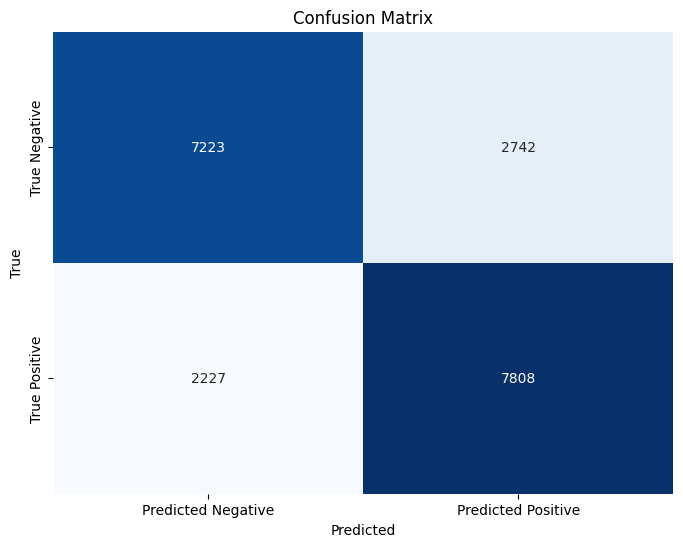

In [32]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Negative', 'Predicted Positive'], 
            yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

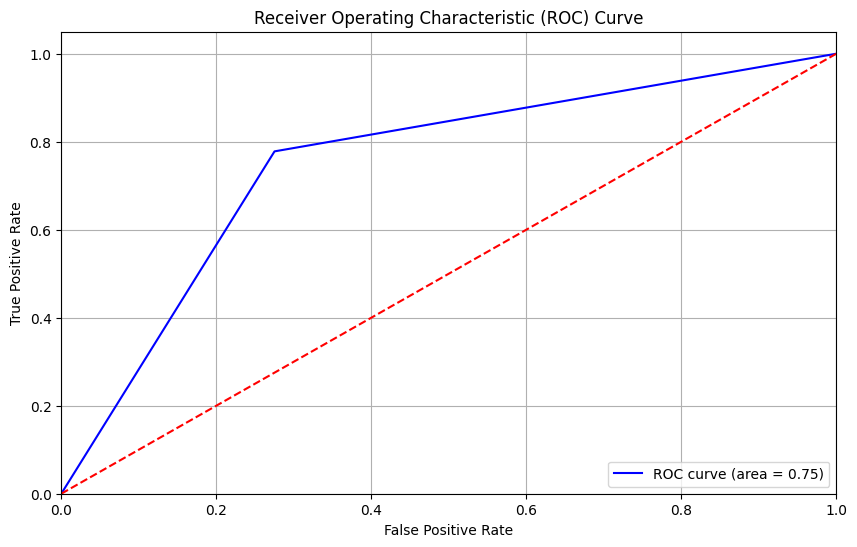

In [33]:
fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [34]:
testset_supervised_prediction = pd.DataFrame({
    'index': range(1, len(test_clean) + 1),  # Create a new index starting from 1
    'predicted_target': all_preds,
})

In [35]:
testset_supervised_prediction

,index,predicted_target
0,1,1
1,2,1
2,3,0
3,4,0
4,5,0
...,...,...
19995,19996,0
19996,19997,1
19997,19998,1
19998,19999,1


In [36]:
testset_supervised_prediction.to_csv('testset_supervised_prediction.csv', index=False)